## Assignment 6 — CNN for Tomato Leaf Disease Classification

## Install Libraries

In [ ]:
!pip install tensorflow numpy pandas matplotlib scikit-learn

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras import models

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


## Check Available Hardware

The available hardware is checked to determine whether a GPU is
available for CNN training.

In [3]:
gpus = tf.config.list_physical_devices("GPU")

if gpus:
    print("GPU is available.")
    print(gpus)
else:
    print("GPU is not available.")
    print("The model will use the CPU.")

GPU is not available.
The model will use the CPU.


## Set Dataset Paths

The uploaded Tomato Leaf Disease dataset contains separate training
and validation directories.
The training directory contains 10,000 images and the validation
directory contains 1,000 images.

In [7]:
dataset_path = r"D:\TY_CLG\DL\Tomato\tomato"

train_path = os.path.join(
    dataset_path,
    "train"
)

val_path = os.path.join(
    dataset_path,
    "val"
)

print("Dataset path:", dataset_path)
print("Training path:", train_path)
print("Validation path:", val_path)

print("\nDataset exists:", os.path.exists(dataset_path))
print("Training folder exists:", os.path.exists(train_path))
print("Validation folder exists:", os.path.exists(val_path))

Dataset path: D:\TY_CLG\DL\Tomato\tomato
Training path: D:\TY_CLG\DL\Tomato\tomato\train
Validation path: D:\TY_CLG\DL\Tomato\tomato\val

Dataset exists: False
Training folder exists: False
Validation folder exists: False


In [10]:
import os

print("D:\\TY_CLG\\DL contents:")
print(os.listdir(r"D:\TY_CLG\DL"))

D:\TY_CLG\DL contents:
['aapl_ticker.csv', 'ass1.pdf', 'ass3.pdf', 'ass6.docx', 'ass6.pdf', 'Tomato.zip', 'Welcome_To_Colab.ipynb']


## Identify Disease Classes

The class folders in the training directory are examined.
Each folder represents one tomato leaf disease category.

In [12]:
class_names = sorted([
    folder
    for folder in os.listdir(train_path)
    if os.path.isdir(os.path.join(train_path, folder))
])

print("Number of classes:", len(class_names))

print("\nDisease Classes:")

for i, class_name in enumerate(class_names):
    print(i, ":", class_name)

Number of classes: 10

Disease Classes:
0 : Tomato___Bacterial_spot
1 : Tomato___Early_blight
2 : Tomato___Late_blight
3 : Tomato___Leaf_Mold
4 : Tomato___Septoria_leaf_spot
5 : Tomato___Spider_mites Two-spotted_spider_mite
6 : Tomato___Target_Spot
7 : Tomato___Tomato_Yellow_Leaf_Curl_Virus
8 : Tomato___Tomato_mosaic_virus
9 : Tomato___healthy


## Count Images

In [13]:
def count_images(folder_path):
    
    counts = {}
    
    for class_name in class_names:
        
        class_path = os.path.join(
            folder_path,
            class_name
        )
        
        count = 0
        
        for file in os.listdir(class_path):
            
            if file.lower().endswith(
                (".jpg", ".jpeg", ".png", ".bmp")
            ):
                count += 1
        
        counts[class_name] = count
    
    return counts


train_counts = count_images(train_path)
val_counts = count_images(val_path)

dataset_summary = pd.DataFrame({
    "Class": class_names,
    "Training Images": [
        train_counts[class_name]
        for class_name in class_names
    ],
    "Validation Images": [
        val_counts[class_name]
        for class_name in class_names
    ]
})

dataset_summary

,Class,Training Images,Validation Images
0,Tomato___Bacterial_spot,1000,100
1,Tomato___Early_blight,1000,100
2,Tomato___Late_blight,1000,100
3,Tomato___Leaf_Mold,1000,100
4,Tomato___Septoria_leaf_spot,1000,100
5,Tomato___Spider_mites Two-spotted_spider_mite,1000,100
6,Tomato___Target_Spot,1000,100
7,Tomato___Tomato_Yellow_Leaf_Curl_Virus,1000,100
8,Tomato___Tomato_mosaic_virus,1000,100
9,Tomato___healthy,1000,100


## Visualize Dataset Distribution.

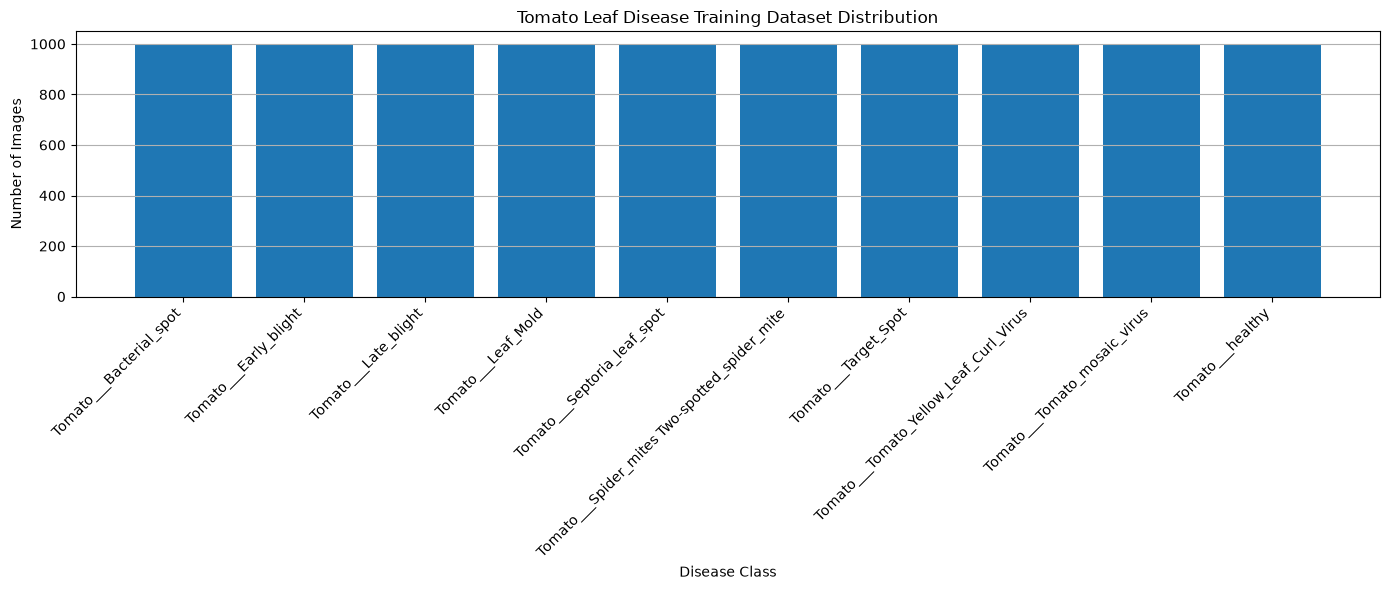

In [14]:
plt.figure(figsize=(14, 6))

plt.bar(
    class_names,
    [train_counts[class_name] for class_name in class_names]
)

plt.title("Tomato Leaf Disease Training Dataset Distribution")
plt.xlabel("Disease Class")
plt.ylabel("Number of Images")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.grid(axis="y")

plt.tight_layout()

plt.show()

## Load Training Dataset

In [15]:
IMG_SIZE = 128
BATCH_SIZE = 32
SEED = 42

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_path,
    labels="inferred",
    label_mode="int",
    class_names=class_names,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

print("Training dataset loaded successfully.")

Found 10000 files belonging to 10 classes.
Training dataset loaded successfully.


## Load the Validation Dataset

The validation images are loaded from the provided validation
directory. The validation dataset is not augmented because it is used to
evaluate the model on unseen images.

In [16]:
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    val_path,
    labels="inferred",
    label_mode="int",
    class_names=class_names,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Validation dataset loaded successfully.")

Found 1000 files belonging to 10 classes.
Validation dataset loaded successfully.


## Verify Dataset Shape

In [17]:
for images, labels in train_dataset.take(1):
    
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    
    print("Single image shape:", images[0].shape)
    print("First 10 labels:", labels[:10].numpy())

Image batch shape: (32, 128, 128, 3)
Label batch shape: (32,)
Single image shape: (128, 128, 3)
First 10 labels: [0 2 4 7 4 9 3 7 4 9]


## Display Sample Images

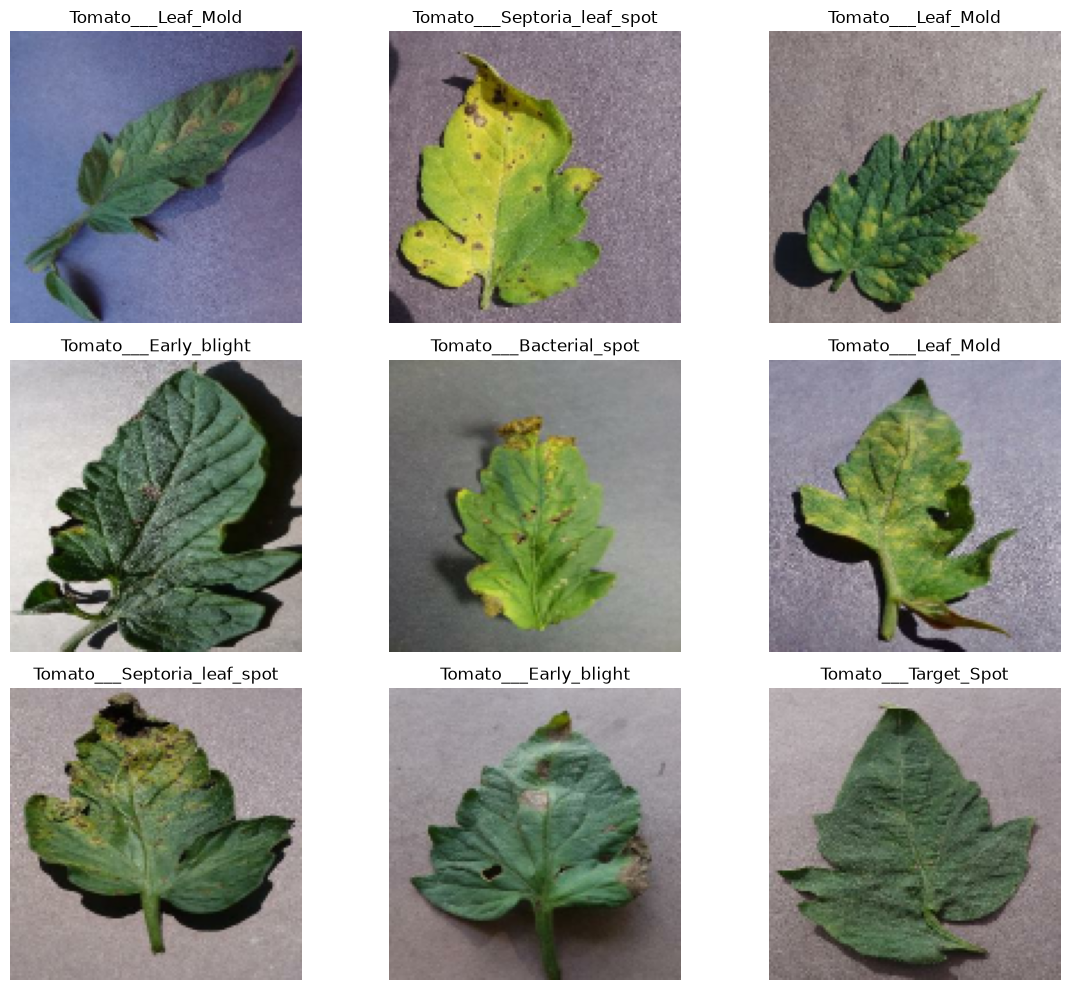

In [18]:
plt.figure(figsize=(12, 10))

for images, labels in train_dataset.take(1):
    
    for i in range(9):
        
        ax = plt.subplot(3, 3, i + 1)
        
        plt.imshow(
            images[i].numpy().astype("uint8")
        )
        
        plt.title(
            class_names[labels[i]]
        )
        
        plt.axis("off")

plt.tight_layout()
plt.show()

## Data Augmentation

Data augmentation is applied to the training images to increase
variation in the training data. Random horizontal flipping, rotation, and zoom are used. Data augmentation helps the CNN generalize better and reduces overfitting.

In [19]:
data_augmentation = tf.keras.Sequential([
    
    layers.RandomFlip(
        "horizontal"
    ),
    
    layers.RandomRotation(
        0.1
    ),
    
    layers.RandomZoom(
        0.1
    )
])

print("Data augmentation created successfully.")

Data augmentation created successfully.


## Visualize Data Augmentation

Augmented versions of a sample image are displayed to demonstrate how data augmentation changes the training images.

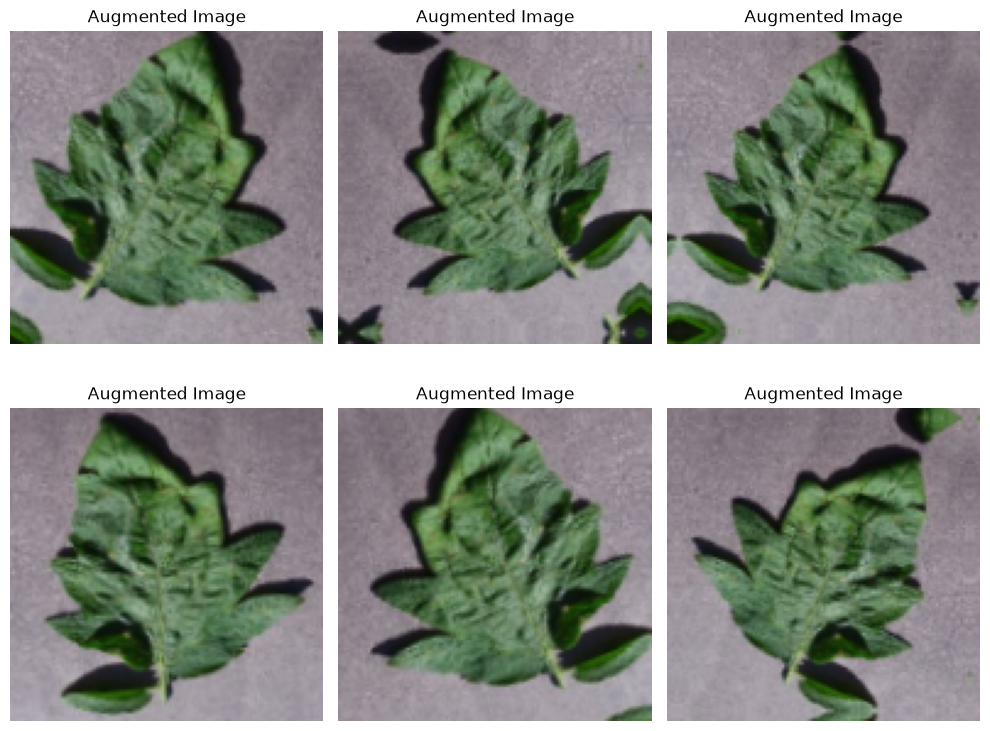

In [20]:
for images, labels in train_dataset.take(1):
    
    sample_image = images[0]
    
    plt.figure(figsize=(10, 8))
    
    for i in range(6):
        
        augmented_image = data_augmentation(
            tf.expand_dims(sample_image, 0),
            training=True
        )[0]
        
        ax = plt.subplot(2, 3, i + 1)
        
        plt.imshow(
            augmented_image.numpy().astype("uint8")
        )
        
        plt.title("Augmented Image")
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

## Build the CNN Model

A Convolutional Neural Network is designed to automatically learn visual features from tomato leaf images.
The CNN consists of three convolutional blocks followed by fully connected layers.
Convolutional layers extract features such as edges, textures, shapes, and disease patterns.
MaxPooling reduces the spatial dimensions of the feature maps.
The final softmax layer produces probabilities for the 10 disease classes.

In [21]:
num_classes = len(class_names)

model = models.Sequential([

    # Input layer
    layers.Input(
        shape=(IMG_SIZE, IMG_SIZE, 3)
    ),

    # Data augmentation
    data_augmentation,

    # Normalize pixel values
    layers.Rescaling(1./255),

    # Convolution Block 1
    layers.Conv2D(
        32,
        (3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D(
        (2, 2)
    ),

    # Convolution Block 2
    layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D(
        (2, 2)
    ),

    # Convolution Block 3
    layers.Conv2D(
        128,
        (3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D(
        (2, 2)
    ),

    # Flatten feature maps
    layers.Flatten(),

    # Fully connected layer
    layers.Dense(
        128,
        activation="relu"
    ),

    # Dropout to reduce overfitting
    layers.Dropout(
        0.5
    ),

    # Output layer
    layers.Dense(
        num_classes,
        activation="softmax"
    )
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,930 (12.61 MB)

 Trainable params: 3,305,930 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

## Understand the Architecture

Your model is:

Input Image
128 × 128 × 3
       ↓
Data Augmentation
       ↓
Rescaling
       ↓
Conv2D – 32 filters
       ↓
MaxPooling
       ↓
Conv2D – 64 filters
       ↓
MaxPooling
       ↓
Conv2D – 128 filters
       ↓
MaxPooling
       ↓
Flatten
       ↓
Dense – 128
       ↓
Dropout – 0.5
       ↓
Softmax – 10 Classes

## Compile the CNN Model

The Adam optimizer is used for training the CNN.
Sparse categorical cross-entropy is selected as the loss function
because this is a multi-class classification problem with integer
class labels. Accuracy is used as the primary training metric.

In [22]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("CNN model compiled successfully.")

CNN model compiled successfully.


## Optimize Dataset Loading

Prefetching is used to prepare future batches while the model is processing the current batch.

In [23]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(
    buffer_size=AUTOTUNE
)

validation_dataset = validation_dataset.prefetch(
    buffer_size=AUTOTUNE
)

print("Dataset optimization completed.")

Dataset optimization completed.


##  Train the CNN Model

The CNN is trained using the 10,000 training images.The provided validation dataset containing 1,000 images is used to monitor model performance.The model is trained for 10 epochs with a batch size of 32.

In [24]:
EPOCHS = 10

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS
)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 97s 295ms/step - accuracy: 0.3527 - loss: 1.7824 - val_accuracy: 0.6300 - val_loss: 1.0498
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 80s 254ms/step - accuracy: 0.5946 - loss: 1.1554 - val_accuracy: 0.6420 - val_loss: 1.0066
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 81s 257ms/step - accuracy: 0.6637 - loss: 0.9601 - val_accuracy: 0.7410 - val_loss: 0.7178
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 78s 248ms/step - accuracy: 0.7183 - loss: 0.8235 - val_accuracy: 0.7760 - val_loss: 0.6535
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 82s 261ms/step - accuracy: 0.7556 - loss: 0.6952 - val_accuracy: 0.8290 - val_loss: 0.5099
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 80s 257ms/step - accuracy: 0.7854 - loss: 0.6350 - val_accuracy: 0.7540 - val_loss: 0.7339
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 81s 259ms/step - accuracy: 0.7994 - loss: 0.5770 - val_accuracy: 0.8210 - val_loss: 0.5253
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 80s 256ms/step - accuracy: 0.8114 - loss: 0

## Training and Validation Accuracy

Training and validation accuracy are plotted to analyze how the CNN
learns over the training epochs.
A significant difference between training and validation accuracy
may indicate overfitting.

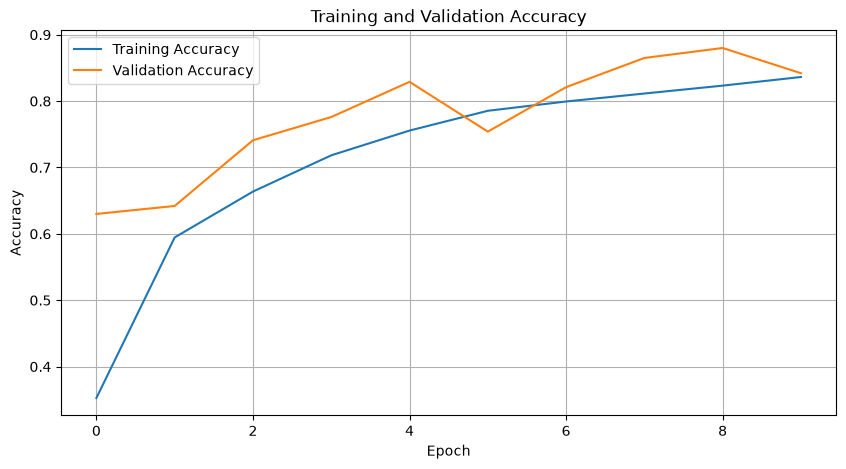

In [25]:
plt.figure(figsize=(10, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title(
    "Training and Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(True)

plt.show()

## Training and Validation Loss

Training and validation loss are plotted to analyze the error of the
CNN during training.
A decreasing loss generally indicates that the model is learning
useful features from the images.

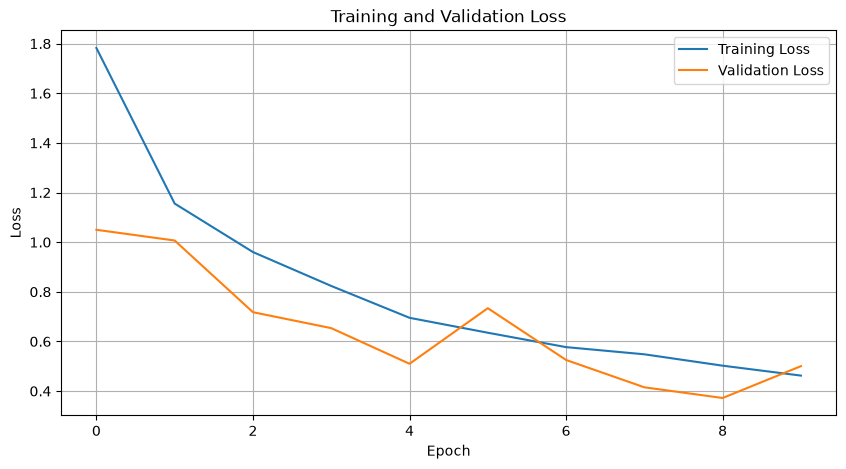

In [26]:
plt.figure(figsize=(10, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title(
    "Training and Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

plt.show()

##  Evaluate the CNN Model

The trained CNN is evaluated on the provided validation dataset.
The validation dataset contains images that were not used during training.

In [27]:
validation_loss, validation_accuracy = model.evaluate(
    validation_dataset,
    verbose=1
)

print(
    f"Validation Loss: {validation_loss:.4f}"
)

print(
    f"Validation Accuracy: {validation_accuracy:.4f}"
)

32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.8420 - loss: 0.5003
Validation Loss: 0.5003
Validation Accuracy: 0.8420


## Generate Predictions

The trained CNN is used to predict the disease class of every image in the validation dataset.
The class with the highest predicted probability is selected as then final prediction.

In [28]:
y_true = []
y_pred = []

for images, labels in validation_dataset:
    
    predictions = model.predict(
        images,
        verbose=0
    )
    
    predicted_classes = np.argmax(
        predictions,
        axis=1
    )
    
    y_true.extend(
        labels.numpy()
    )
    
    y_pred.extend(
        predicted_classes
    )

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Predictions generated successfully.")
print("Total validation predictions:", len(y_pred))

Predictions generated successfully.
Total validation predictions: 1000


## Accuracy

Accuracy measures the percentage of validation images that were correctly classified by the CNN.

In [29]:
accuracy = accuracy_score(
    y_true,
    y_pred
)

print(
    f"Accuracy: {accuracy:.4f}"
)

Accuracy: 0.8420


## Precision

Precision measures how many images predicted as a particular disease
class actually belong to that class.
Macro averaging is used so that all 10 disease classes receive equal
importance.

In [30]:
precision = precision_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

print(
    f"Precision: {precision:.4f}"
)

Precision: 0.8605


## Recall

Recall measures how effectively the CNN identifies images belonging
to each disease class. Macro averaging gives equal importance to all classes.

In [31]:
recall = recall_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

print(
    f"Recall: {recall:.4f}"
)

Recall: 0.8420


## F1-Score

F1-score is the harmonic mean of precision and recall.
A higher F1-score indicates a better balance between precision and recall.

In [32]:
f1 = f1_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

print(
    f"F1-Score: {f1:.4f}"
)

F1-Score: 0.8422


## Classification Report

In [33]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    zero_division=0
)

print(report)

                                               precision    recall  f1-score   support

                      Tomato___Bacterial_spot       0.95      0.86      0.90       100
                        Tomato___Early_blight       0.70      0.93      0.80       100
                         Tomato___Late_blight       0.92      0.68      0.78       100
                           Tomato___Leaf_Mold       0.87      0.81      0.84       100
                  Tomato___Septoria_leaf_spot       0.67      0.91      0.77       100
Tomato___Spider_mites Two-spotted_spider_mite       0.93      0.67      0.78       100
                         Tomato___Target_Spot       0.83      0.75      0.79       100
       Tomato___Tomato_Yellow_Leaf_Curl_Virus       0.95      0.91      0.93       100
                 Tomato___Tomato_mosaic_virus       0.81      1.00      0.89       100
                             Tomato___healthy       0.98      0.90      0.94       100

                                     accu

## Confusion Matrix

The confusion matrix shows which diseases are being confused with each other.

In [35]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_true,
    y_pred
)

print(cm)

[[ 86   7   2   0   2   0   0   3   0   0]
 [  1  93   3   0   0   0   1   1   1   0]
 [  1  21  68   7   2   0   0   1   0   0]
 [  0   2   0  81  12   0   0   0   5   0]
 [  0   4   0   4  91   0   0   0   1   0]
 [  0   0   0   0   5  67  14   0  13   1]
 [  0   2   0   0  15   3  75   0   4   1]
 [  3   3   0   1   0   2   0  91   0   0]
 [  0   0   0   0   0   0   0   0 100   0]
 [  0   0   1   0   9   0   0   0   0  90]]


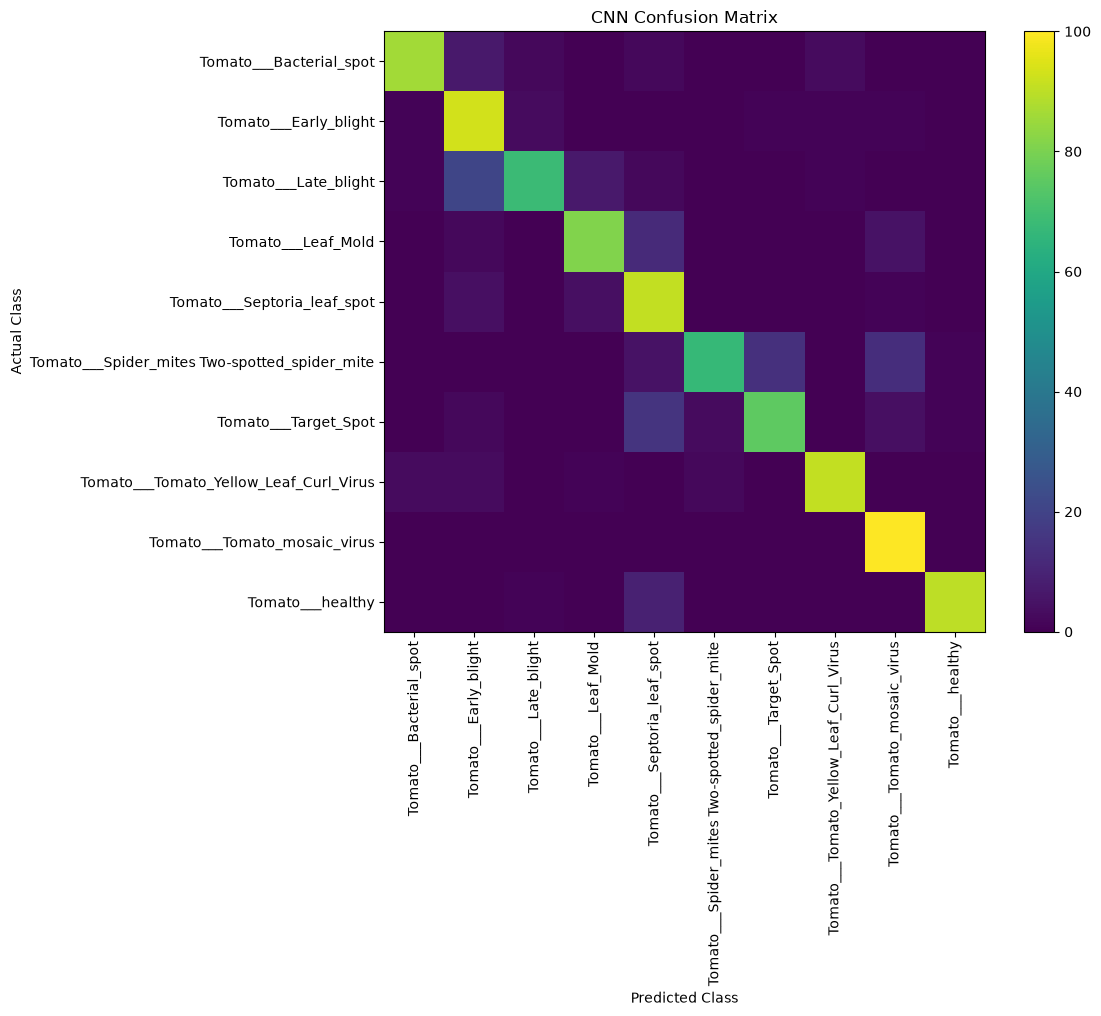

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))

plt.imshow(cm)

plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks(
    range(len(class_names)),
    class_names,
    rotation=90
)

plt.yticks(
    range(len(class_names)),
    class_names
)

plt.colorbar()

plt.tight_layout()
plt.show()

## Create a Final Results Table

In [37]:
results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

results["Score"] = results["Score"].round(4)

print(results)

      Metric   Score
0   Accuracy  0.8420
1  Precision  0.8605
2     Recall  0.8420
3   F1-Score  0.8422


In [41]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,917,792 (37.83 MB)

 Trainable params: 3,305,930 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,611,862 (25.22 MB)

## Save the Trained Model

In [42]:
model.save("tomato_disease_cnn.keras")

print("Model saved successfully!")

Model saved successfully!
